In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

In [6]:
docs=WebBaseLoader(urls).load()

In [7]:
len(docs)

3

In [8]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=500, chunk_overlap=100)

In [9]:
doc_splits=text_splitter.split_documents(docs)

In [10]:
len(doc_splits)

92

In [11]:
vectorstore=Chroma.from_documents(documents=doc_splits, embedding=embeddings, collection_name="self_rag_test")

In [12]:
retriever=vectorstore.as_retriever()

In [13]:
retriever.invoke("What is agent?")

[Document(metadata={'title': "LLM Powered Autonomous Agents | Lil'Log", 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'language': 'en', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the qua

In [14]:
from langchain_core.tools.retriever import create_retriever_tool 
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_blog_posts",
    "search and return information about agents, prompt engineering and adversarial attack on LLMs from the blog posts provided"
    )

In [15]:
tools=[retriever_tool]

In [16]:
from typing import List
from typing_extensions import TypedDict

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# data model
class GraderDocuments(BaseModel):
    "Binary score for relevance check on retrieved documents"
    binary_score: str = Field(description="yes if the document is relevant, no otherwise")

# llm with function call
structured_llm_grader=llm.with_structured_output(GraderDocuments)

In [18]:
# Prompt
system_prompt_Grader = """You are a grader checking if a document is relevant to a user's question. The check has to be done very strictly ..
If the document has words or meanings related to the question, mark it as relevant.
Give a simple 'yes' or 'no' answer to show if the document is relevant or not. """

grade_prompt = ChatPromptTemplate. from_messages(
    [
        ("system", system_prompt_Grader),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

In [32]:
retrieval_grader=grade_prompt| structured_llm_grader
question="agent memory"
docs_test=retriever.invoke(question)

In [33]:
docs_test[0].page_content

"Memory stream: is a long-term memory module (external database) that records a comprehensive list of agents’ experience in natural language.\n\nEach element is an observation, an event directly provided by the agent.\n- Inter-agent communication can trigger new natural language statements.\n\n\nRetrieval model: surfaces the context to inform the agent’s behavior, according to relevance, recency and importance.\n\nRecency: recent events have higher scores\nImportance: distinguish mundane from core memories. Ask LM directly.\nRelevance: based on how related it is to the current situation / query.\n\n\nReflection mechanism: synthesizes memories into higher level inferences over time and guides the agent’s future behavior. They are higher-level summaries of past events (<- note that this is a bit different from self-reflection above)\n\nPrompt LM with 100 most recent observations and to generate 3 most salient high-level questions given a set of observations/statements. Then ask LM to ans

In [40]:
print(retrieval_grader.invoke({"document": docs_test[0].page_content, "question": question}))

binary_score='yes'


In [41]:
print(retrieval_grader.invoke({"document": docs_test[0].page_content, "question": 'Hi, how are you?'}))

binary_score='no'


In [19]:
from langsmith import Client
client = Client()
prompt = client.pull_prompt("rlm/rag-prompt") 
prompt.pretty_print()


================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [20]:
rag_chain=prompt | llm

In [50]:
generation=rag_chain.invoke({"question": question,'context':docs_test})

In [52]:
generation.pretty_print()

================================== Ai Message ==================================

In a LLM-powered autonomous agent system, the agent's memory consists of short-term memory, which utilizes in-context learning to learn, and long-term memory, which retains and recalls infinite information over extended periods through an external vector store and fast retrieval. The long-term memory module is also referred to as a "memory stream" that records a comprehensive list of the agent's experiences in natural language. This allows the agent to retain and recall information over time.


# Hallucination Grader

In [21]:
# Hallucination Grader
class GraderHallucination(BaseModel):
    "Binary score for hallucination present in generated answer"
    
    binary_score: str = Field(description="Answer is grounded in the facts, 'yes' or 'no'")

# llm with function call
structured_llm_hallucination_grader=llm.with_structured_output(GraderHallucination)

In [22]:
# Prompt for hallucination check
system_prompt_Hallucination_Grader = """You are a grader checking if an.LLM-generation is grounded in or supported by a set of retrieved facts.
Give a simple 'yes' or 'no' answer. 'Yes' means the generation is grounded in or supported by a set of retrieved the facts.
No explanations is needed or allowed. only direct answer 'yes' or 'no' is expected."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt_Hallucination_Grader),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

In [23]:
hallucination_grader=hallucination_prompt | structured_llm_hallucination_grader

In [53]:
question

'agent memory'

In [61]:
print(hallucination_grader.invoke({"documents": docs_test, "generation": generation}))

binary_score='yes'


# Answer Grader

In [24]:
# data model
class GraderAnswer(BaseModel):
    "Binary score to assesss answer adress the question"
    
    binary_score: str = Field(description="Answer addresses the question, 'yes' or 'no'")

In [25]:
# llm with function call
structured_llm_answer_grader=llm.with_structured_output(GraderAnswer)

In [26]:
# Prompt
system_prompt_Answer_Grader = """You are a grader assessing whether an answer addresses / resolves a question \n
    Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question. No need any explanation, just give 'yes' or 'no'."""
answer_prompt = ChatPromptTemplate. from_messages(
    [
        ("system", system_prompt_Answer_Grader),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),   
    ]
)

In [27]:
answer_grader=answer_prompt | structured_llm_answer_grader

In [ ]:
print(answer_grader.invoke({"question": question, "generation": generation}))

binary_score='yes'


# Question-ReWriter

In [28]:
question_rewriter_system_prompt = """You are a question re-writer that converts an input question into a better optimized version for vector store retrieval doc
You are given both a question and a document.
- First, check if the question is relevant to the document by identifying a connection or relevance between them.
- If there is a little relevancy, rewrite the question based on the semantic intent of the question and the context of the document.
- If no relevance is found, simply return "question not relevant .no need of explanation at this case only."
Your goal is to ensure the rewritten question aligns well with the document for better retrieval."""

re_write_prompt = ChatPromptTemplate. from_messages(
    [
        ("system", question_rewriter_system_prompt),
        (
            "human","""Here is the initial question: \n\n {question} \n,
            Here is the document: \n\n {documents} \n ,
            Formulate an improved question. if possible other return 'question not relevant'."""
        ),

    ]
)

In [30]:
from langchain_core.output_parsers import StrOutputParser
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [36]:
question="Who is the CEO of Apple?"

In [37]:
print(question_rewriter.invoke({"question": question, "documents": docs_test[0].page_content}))

The initial question "Who is the CEO of Apple?" does not seem to have any connection or relevance to the provided document. The document appears to discuss a generative agent architecture, its components, and how it processes information, but it does not mention Apple or its CEO.

Therefore, I return: "question not relevant."


# creating the functions 

In [39]:
from typing import List
from typing_extensions import TypedDict
class AgentState(TypedDict):
    question: str
    generation: str
    documents: List[str]
    filter_documents: List[str]
    unfilter_documents: List[str]

In [40]:
def retrieve(state: AgentState):
    print('Documents are retrieving from the vector DB based on the question')
    question=state['question']
    documents=retriever.invoke(question)
    return {'documents':documents, 'question':question}

In [41]:
def grade_documents(state: AgentState):
    print('Checking the relevance of retrieved documents to the question')
    question=state['question']
    documents=state['documents']
    
    filter_documents=[]
    unfilter_documents=[]
    for doc in documents:
        score=retrieval_grader.invoke({"document": doc, "question": question})
        grade=score.binary_score
        
        if grade=='yes':
            print("Documents are relevant to the question")
            filter_documents.append(doc)
        else:
            print("Documents are not relevant to the question")
            unfilter_documents.append(doc)
    if len(filter_documents)>1:
        return {'unfilter_documents': unfilter_documents, 'filter_documents': [], 'question': question}
    else:
        return {'unfilter_documents': [], 'filter_documents': filter_documents, 'question': question}

In [42]:
def decide_to_generate(state: AgentState):
    print("Acessing the Graded documents to decide whether to generate an answer")
    state['question']
    unfilter_documents=state['unfilter_documents']
    filter_documents=state['filter_documents']
    
    if unfilter_documents:
        print("These documents are not relevant to question, so Transforming the question")
        return "transform_query"
    else:
        print("These documents are relevant to question, so Generating the answer")
        return "generate"

In [43]:
def generate(state: AgentState):
    print("Generating an answer based on the question and the relevant documents")
    question=state['question']
    documents=state['documents']
    
    generation=rag_chain.invoke({"question": question,'context':documents})
    return {"generation": generation, "question": question, "documents": documents}

In [73]:
def transform_query(state: AgentState):
    print("Rewriting the question based on the relevance of documents")
    question=state['question']
    documents=state['documents']
    
    print(f"This is my document: {documents}")
    response=question_rewriter.invoke({"question": question, "documents": documents})
    print(f"___RESPONSE___: {response}")
    
    if 'question not relevant' in response:
        print("The question is not relevant to the documents")
        return {'question':response, 'documents': documents,'generation': 'The question was not at all relevant to the documents'}
    else:
        return {'documents': documents, 'question': response}

In [45]:
def decide_to_generate_after_transformation(state: AgentState):
    print("Deciding whether to generate after question transformation")
    question=state['question']
    
    if 'question not relevant' in question:
        print("The question is still not relevant to the documents after transformation, so no need to generate answer")
        return "query_not_at_all_relevant"
    else:
        print("The question is relevant to the documents after transformation, so generating the answer")
        return "Retriever"

In [46]:
def grade_generation_VS_documents_and_question(state: AgentState):
    print("____CHECKING HALLUCINATIONS____")
    question=state['question']
    documents=state['documents']
    generation=state['generation']
    
    score=hallucination_grader.invoke({"documents": documents, "generation": generation})
    grade=score.binary_score
    
    # checking hallucinatons
    if grade=="yes":
        print("The generation is grounded in the retrieved documents, now checking if the answer addresses the question")
        
        score_answer=answer_grader.invoke({"question": question, "generation": generation})
        grade_answer=score_answer.binary_score
        
        if grade_answer=="yes":
            print("The answer addresses the question")
            return "useful"
        else:
            print("The answer does not address the question, so Re-Trying Transform Query")
            return "not_useful"
    else:
        print("The generation is not grounded in the retrieved documents, so Re-Trying Transform Query")
        return "not_useful"

In [47]:
from langgraph.graph import StateGraph, START, END

In [74]:
workflow=StateGraph(AgentState)
workflow.add_node("Doc_vector_Retrieve", retrieve)
workflow.add_node('Grading_Generated_Document', grade_documents)
workflow.add_node('Content_Generator', generate)
workflow.add_node('Transform_User_Query', transform_query)

In [75]:
workflow.add_edge(START,'Doc_vector_Retrieve')
workflow.add_edge('Doc_vector_Retrieve','Grading_Generated_Document')

workflow.add_conditional_edges('Grading_Generated_Document',
                               decide_to_generate,
                               {
                                   'generate': 'Content_Generator',
                                   'transform_query': 'Transform_User_Query'
                               }
                            )

workflow.add_conditional_edges('Content_Generator',
                               grade_generation_VS_documents_and_question,
                               {
                                   'useful':END,
                                   'not_useful':'Transform_User_Query'
                               }
                               
                            )

workflow.add_conditional_edges('Transform_User_Query',
                               decide_to_generate_after_transformation,
                               {
                                   'Retriever': 'Doc_vector_Retrieve',
                                   'query_not_at_all_relevant': END
                               }
                            )

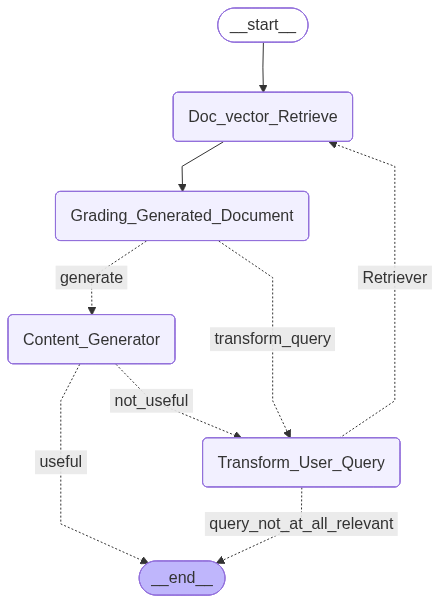

In [76]:
app=workflow.compile()
app

In [60]:
inputs={'question':'Explain how the different types of agent memory work and compare them.'}

In [61]:
app.invoke(inputs)['generation']

Documents are retrieving from the vector DB based on the question
Checking the relevance of retrieved documents to the question
Documents are relevant to the question
Documents are relevant to the question
Documents are relevant to the question
Documents are relevant to the question
Acessing the Graded documents to decide whether to generate an answer
These documents are relevant to question, so Generating the answer
Generating an answer based on the question and the relevant documents
____CHECKING HALLUCINATIONS____
The generation is grounded in the retrieved documents, now checking if the answer addresses the question
The answer addresses the question


AIMessage(content='There are two main types of agent memory: short-term memory and long-term memory. Short-term memory utilizes in-context learning to store information temporarily, whereas long-term memory retains and recalls infinite information over extended periods using an external vector store and fast retrieval. \n\nIn the context of human memory, there are also sensory memory, short-term memory (or working memory), and long-term memory (with subtypes explicit/declarative and implicit/procedural). \n\nThe long-term memory in agents can be further categorized like human memory, but the key difference lies in how agents use external storage for long-term memory, unlike human brains.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 2980, 'total_tokens': 3105, 'completion_time': 0.307948045, 'completion_tokens_details': None, 'prompt_time': 0.106535515, 'prompt_tokens_details': None, 'queue_time': 0.070988362, 'total_time': 0.4144

In [62]:
inputs={'question':'Who is a prompt engineering?'}

In [63]:
app.invoke(inputs)['generation']

Documents are retrieving from the vector DB based on the question
Checking the relevance of retrieved documents to the question
Documents are relevant to the question
Documents are relevant to the question
Documents are not relevant to the question
Documents are relevant to the question
Acessing the Graded documents to decide whether to generate an answer
These documents are not relevant to question, so Transforming the question
Rewriting the question based on the relevance of documents
This is my document: [Document(metadata={'title': "Prompt Engineering | Lil'Log", 'language': 'en', 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for aut

AIMessage(content='Prompt engineering refers to methods for communicating with Large Language Models (LLMs) to steer their behavior for desired outcomes without updating the model weights. It is also known as In-Context Prompting. There is no specific person known as a "prompt engineer," but rather it is a concept and an empirical science.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 2323, 'total_tokens': 2386, 'completion_time': 0.146791203, 'completion_tokens_details': None, 'prompt_time': 0.06460904, 'prompt_tokens_details': None, 'queue_time': 0.045304639, 'total_time': 0.211400243}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d33a9-703c-7e83-828e-58232d56aeba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2323, 'output_tokens': 63, 't

In [65]:
inputs={'question':'What is role of data structure while creating agentic pattren?'}

In [66]:
app.invoke(inputs)['generation']

Documents are retrieving from the vector DB based on the question
Checking the relevance of retrieved documents to the question
Documents are relevant to the question
Documents are not relevant to the question
Documents are not relevant to the question
Documents are not relevant to the question
Acessing the Graded documents to decide whether to generate an answer
These documents are relevant to question, so Generating the answer
Generating an answer based on the question and the relevant documents
____CHECKING HALLUCINATIONS____
The generation is grounded in the retrieved documents, now checking if the answer addresses the question
The answer addresses the question


AIMessage(content='While creating an agentic pattern, the role of data structure is not explicitly mentioned in the context. However, data structures like tree structures are used to organize environment information. The agent also utilizes short-term and long-term memory, which can be considered as data structures that store and retrieve information. \n\nIf you could provide more context, I may be able to give a more precise answer.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 2419, 'total_tokens': 2497, 'completion_time': 0.195341185, 'completion_tokens_details': None, 'prompt_time': 0.077964096, 'prompt_tokens_details': None, 'queue_time': 0.045227153, 'total_time': 0.273305281}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d33ac-adbd-7671-a903-4ad695480cb3-0', to

In [77]:
inputs={'question':'Who is a first president of the India?'}

In [78]:
app.invoke(inputs)['generation']

Documents are retrieving from the vector DB based on the question
Checking the relevance of retrieved documents to the question
Documents are not relevant to the question
Documents are not relevant to the question
Documents are not relevant to the question
Documents are not relevant to the question
Acessing the Graded documents to decide whether to generate an answer
These documents are relevant to question, so Generating the answer
Generating an answer based on the question and the relevant documents
____CHECKING HALLUCINATIONS____
The generation is grounded in the retrieved documents, now checking if the answer addresses the question
The answer does not address the question, so Re-Trying Transform Query
Rewriting the question based on the relevance of documents
This is my document: [Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/', 'title': "Adversarial Attacks on LLMs | Lil'Log", 'language': 'en', 'description': 'The use of large language 

'The question was not at all relevant to the documents'